In [ ]:
# Initialize Otter
import otter
grader = otter.Notebook("hw01.ipynb")

# HW 01: Permutation Testing

You must submit this assignment to **Gradescope** by the **on-time deadline**. Please refer to the course syllabus for the **grace period policy**. **No late submissions beyond the grace period will be accepted.**

While the course staff is happy to help if you encounter submission difficulties, we may not be able to respond to **last-minute or late-night** requests for assistance. **We strongly encourage you to submit your work to Gradescope several hours before the stated deadline.** This will give you ample time to contact the course staff if you need submission support.

After completing **Homework 01**, submit the generated **ZIP** file to the **HW 01** assignment on **Gradescope**.


## Before You Start


### Autograder and Answer Cells

For each question in the assignment, please write down your answer in the answer cell(s) right below the question. 

We understand that it is helpful to have extra cells breaking down the process toward reaching your final answer. If you happen to create new cells *below* your answer to run code, **NEVER** add cells between a question cell and the answer cell below it. It may cause errors when we run the autograder.


**Important note: The local autograder tests will not be comprehensive.** They are meant to give you some useful feedback, but it's your responsibility to ensure your response answers the question correctly. There may be other tests that we run when scoring your notebooks. We **strongly recommend** that you check your solutions yourself rather than just relying on the test cells.

### Initialize your environment


In [ ]:
import numpy as np
np.random.seed(42)
import matplotlib
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

### Preliminary: Jupyter Shortcuts ###

Here are some useful Jupyter notebook keyboard shortcuts.  To learn more keyboard shortcuts, go to **Help -> Keyboard Shortcuts** in the menu above. 

Here are a few we like:
1. `ctrl`+`return` : *run the current cell*
2. `shift`+`return`: *run the current cell and move to the next*
3. `esc` : *command mode* (may need to press before using any of the commands below)
    * `a` : *create a cell above*
    * `b` : *create a cell below*
    * `dd` : *delete a cell*
    * `m` : *convert a cell to markdown*
    * `y` : *convert a cell to code*

### `NumPy`

`NumPy` is the numerical computing module. Here's a quick recap of `NumPy`. For more review, read the following materials.

- **[NumPy Quick Start Tutorial](https://numpy.org/doc/stable/user/quickstart.html)**
- **[NumPy Review](https://mtu.instructure.com/courses/1527249/files/118524356?module_item_id=24078621&fd_cookie_set=1)**
- **[Stanford CS231n NumPy Tutorial](http://cs231n.github.io/python-numpy-tutorial/#numpy)**
- **[The Data 8 Textbook Chapter on NumPy](https://www.inferentialthinking.com/chapters/05/1/Arrays)**

**Jupyter pro-tip**: Pull up the documentation for any function in Jupyter by running a cell with
the function name and a `?` at the end:

In [ ]:
np.arange?

**Another Jupyter pro-tip**: Pull up the documentation for any function in Jupyter by typing the function name, then `<Shift><Tab>` on your keyboard. This is super convenient when you forget the order of the arguments to a function. You can press `<Tab>` multiple times to expand the docs and reveal additional information.

Try it on the function below:

In [ ]:
np.linspace

### Preliminary: LaTeX 

You should use LaTeX to format math in your answers. If you aren't familiar with LaTeX, don't worry. It's not hard to use in a Jupyter notebook. Just place your math in between dollar signs within Markdown cells:

`$ f(x) = 2x $` becomes $ f(x) = 2x $.

If you have a longer equation, use double dollar signs to place it on a line by itself:

`$$ \sum_{i=0}^n i^2 $$` becomes:

$$ \sum_{i=0}^n i^2$$


You can align multiple lines using the `&` anchor, `\\` newline, in an `align` block as follows:

```
\begin{align}
f(x) &= (x - 1)^2 \\
&= x^2 - 2x + 1
\end{align}
```
becomes

\begin{align}
f(x) &= (x - 1)^2 \\
&= x^2 - 2x + 1
\end{align}

* [This PDF](https://mtu.instructure.com/courses/1527249/files/118523182?module_item_id=24078678) has some handy LaTeX tips.
* [For more about basic LaTeX formatting, you can read this article.](https://www.overleaf.com/learn/latex/Mathematical_expressions)

### Preliminary: Sums 

Here's a recap of some basic algebra written in sigma notation. The facts are all just applications of the ordinary associative and distributive properties of addition and multiplication, written compactly and without the possibly ambiguous "$\dots$". But if you are ever unsure of whether you're working correctly with a sum, you can always try writing $\sum_{i=1}^n a_i$ as $a_1 + a_2 + \cdots + a_n$ and see if that helps.

You can use any reasonable notation for the index over which you are summing, just as in Python you can use any reasonable name in `for name in list`. Thus $\sum_{i=1}^n a_i = \sum_{k=1}^n a_k$.

- $\sum_{i=1}^n (a_i + b_i) = \sum_{i=1}^n a_i + \sum_{i=1}^n b_i$
- $\sum_{i=1}^n d = nd$
- $\sum_{i=1}^n (ca_i + d) = c\sum_{i=1}^n a_i + nd$



<br/><br/>
<hr style="border: 5px solid #8a8c8c;" />
<hr style="border: 1px solid #ffcd00;" />

## Visualizing Distributions

Visualizing distributions, both categorical and numerical, helps us understand variability. You can visualize numerical distributions by drawing histograms ([Chapter 7.2 link](https://inferentialthinking.com/chapters/07/2/Visualizing_Numerical_Distributions.html#histogram)), which look like bar charts but represent proportions through the *areas* of the bars instead of the heights or lengths.


---

###  Matplotlib Tutorial

We will learn industry——and academia——standard libraries for exploring and visualizing data, including `matplotlib` ([official website](https://matplotlib.org/)).
In this exercise, you will use the `hist` function in `matplotlib`. In a previous code cell, we imported the matplotlib library as `plt`, which allows us to call `plt.hist()`.

To start off, suppose we want to plot the probability distribution of the number of spots on a single roll of a die. That should be a flat histogram since the chance of each of the values 1 through 6 is $\frac{1}{6}$. Here is a first attempt at drawing the histogram.

In [ ]:
faces = range(1, 7)
plt.hist(faces)

This default plot is not helpful. We have to choose some arguments to get a visualization that we can interpret. 

Note that the second printed line shows the left ends of the default bins, as well as the right end of the last bin. The first line shows the counts in the bins. If you don't want the printed lines, you can add a semi-colon `;` at the end of the call to `plt.hist`, but we'll keep the lines for now.

Let's redraw the histogram with bins of unit length centered at the possible values. By the end of the tutorial, you'll see a reason for centering. 

In [ ]:
unit_bins = np.arange(0.5, 6.6)
plt.hist(faces, bins=unit_bins)

We need to see the edges of the bars! Let's specify the edge color `ec` to be `white`. [Here](https://matplotlib.org/3.5.3/gallery/color/named_colors.html) are all the colors you could use, but do try to drag yourself away from the poetic names.

In [ ]:
plt.hist(faces, bins=unit_bins, ec='white')

That's much better, but look at the vertical axis. It is not drawn to the density scale ([Chapter 7.2 link](https://inferentialthinking.com/chapters/07/2/Visualizing_Numerical_Distributions.html#the-vertical-axis-density-scale)). We want a histogram of a probability distribution, so the total area should be 1. We just have to ask for that by setting `density` to `True`.

In [ ]:
plt.hist(faces, bins=unit_bins, ec='white', density=True)

That's the probability histogram of the number of spots on one roll of a die. The proportion is $\frac{1}{6}$ in each of the bins.

Finally, we can set the opacity, or transparency, of the bars with the `alpha` parameter, which is a value from 0 to 1. For 70% opacity:


In [ ]:
plt.hist(faces, bins=unit_bins, ec='white', density=True, alpha=0.7)

**Note/Reminder**: The above cells printed the counts/proportions and bin boundaries with the visualization. This was intentional on our part to show you how `plt.hist()` returned different values per plot. You may use a semicolon `;` on the last line to suppress additional display as needed.

---
## Question 1

A quality control engineer records the weights (in grams) of manufactured parts.

Define a function `plot_weights` that takes an array of weights and draws a histogram of the data using **bins of width 5 grams**.

Your histogram should satisfy the following requirements:

- Use bins of width **5**.
- Draw the histogram on the **density** scale.
- Use **gray** edges for the bars.
- Set the bar **opacity to 75%**.

The left-most bin should begin at the nearest multiple of 5 that is less than or equal to the minimum weight, and the right-most bin should end at the nearest multiple of 5 that is greater than or equal to the maximum weight.

Assign the histogram to a variable named `weight_hist`.

No title or axis labels are required.

**Data:**

```python
weights = [48.5, 50.2, 51.7, 53.8, 55.1,
           56.4, 58.9, 60.0, 61.8, 64.2]
```

**Hint:**
- You may find `min()`, `max()`, `np.floor()`, `np.ceil()`, and `np.arange()` helpful.
- See `plt.hist()` [documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html).
- If you implement the function correctly, you should get a plot like this:
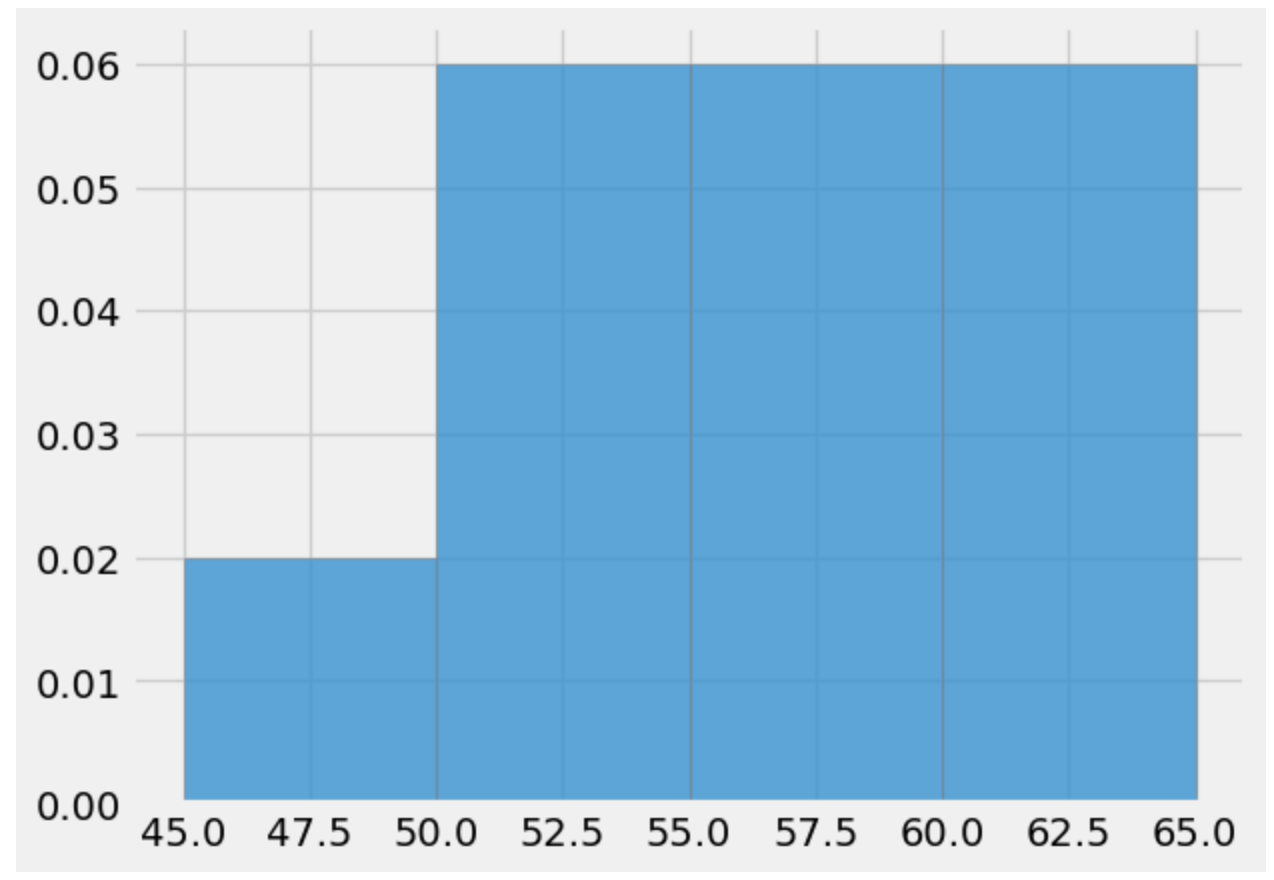

In [ ]:
def plot_weights(arr):
    # Define bins with width 5
    weight_bins = ...

    # Draw the histogram
    histplot = ...

    return histplot

weights = [48.5, 50.2, 51.7, 53.8, 55.1, 56.4, 58.9, 60.0, 61.8, 64.2]
histplot = plot_weights(weights)

In [ ]:
grader.check("q1")

<br/><br/>
<hr style="border: 5px solid #8a8c8c;" />
<hr style="border: 1px solid #ffcd00;" />

##  Birthweights

You can perform [hypothesis testing using the permutation test](https://inferentialthinking.com/chapters/12/1/AB_Testing.html) (Chapter 12.1). **Before continuing, we HIGHLY ENCOURAGE you to read the above linked chapters, on which this exercise is DIRECTLY BASED.**

In a particular medical study, a sample of newborn babies was obtained from a large hospital system.  We will treat the data as if it were a simple random sample, though the sampling was done in multiple stages. Deborah Nolan and Terry Speed discuss the larger dataset in [Stat Labs](https://www.stat.berkeley.edu/~statlabs/).

One of the aims of the study was to see whether maternal smoking was associated with birth weight. **Run the below cell**, which assigns `nonsmoker_births` to a list of birth weights of the babies of the non-smoking mothers (of which there are 715) and `smoker_births` to a list of birth weights of the babies of the smoking mothers (of which there are 459). 

In [ ]:
# Just run this cell. You will learn these functions soon!

import pandas as pd
births_df = pd.read_csv("births.csv")

nonsmoker_births = births_df[~births_df['Maternal Smoker']]['Birth Weight'].values
print(len(nonsmoker_births))

smoker_births = births_df[births_df['Maternal Smoker']]['Birth Weight'].values
print(len(smoker_births))

Suppose that we overlay the distributions of birthweights from the two groups:

In [ ]:
# Just run this cell. You will learn these functions soon!

import seaborn as sns
sns.histplot(births_df, x="Birth Weight", hue="Maternal Smoker");
plt.title("Distribution of Birth Weight");

The distribution of the weights of the babies born to mothers who smoked appears to be based slightly to the left of the distribution corresponding to non-smoking mothers. The weights of the babies of the mothers who smoked seem lower on average than those of the babies of the non-smokers.

<br/>
Similar to the original study (and the book chapter), we'd like to study whether this difference reflects just chance variation or perhaps a difference in the distributions in the larger population. Suppose we propose the following two hypotheses:

> **Null hypothesis (H0)**: In the population, the distribution of birth weights of babies is the same for mothers who don’t smoke as for mothers who do. The (observed) difference in the sample is due to chance.

> **Alternative hypothesis (H1)**: In the population, the babies of the mothers who smoke have a <i>**different**</i> birth weight, on average, than the babies of the non-smokers.

We would like to perform hypothesis testing using the permutation test. One way to do so is to compute an observed test statistic and then compare it with multiple simulated test statistics generated through random permutations.

<br/>

---

### Question 2

Suppose that we choose a reasonable test statistic as the **absolute difference** between the **median** birth weights of the two groups (i.e., the babies of non-smokers and the babies of mothers who smoke). 

In the below cell, assign `observed_difference` to the **observed test statistic** given our original sample of `nonsmoker_births` and `smoker_births`.

**Hint**: This test statistic is slightly different from what is presented in the  textbook, [Chapter 12.1 link](https://inferentialthinking.com/chapters/12/1/AB_Testing.html#the-hypotheses).

**Hint**: `nonsmoker_births` and `smoker_births` are NumPy arrays.  Look to the NumPy documentation on how to take the mean and of an array. 

**Note**: The data used in this example is different from the one used in the book.  Therefore, the median birth weights of the two groups (smokers) and (non-smokers) may differ from what is reported in the textbook.

In [ ]:
observed_difference = ...
observed_difference

In [ ]:
grader.check("q2")

<!-- BEGIN QUESTION -->

<br/>

---

### Question 3

Before we write any code, let’s review the idea of hypothesis testing with the permutation test. We first simulate the experiment many times (say, 10,000 times) through random permutation (i.e., without replacement). Assuming that the null hypothesis holds, this process will produce an empirical distribution of a predetermined test statistic. Then, we use this empirical distribution to compute an **empirical p-value**(, which is then compared against a particular cutoff threshold in order to accept or reject our null hypothesis. 

In the below cell, answer the following questions:
* What does an empirical p-value from a permutation test mean in this particular context of birthweights and maternal smoking habits?
* Suppose the resulting empirical p-value $p \leq 0.01$, where $0.01$ is our p-value cutoff threshold. Do we accept or reject the null hypothesis? Why?


_Type your answer here, replacing this text._

<!-- END QUESTION -->

<br/>

---

### Question 4

Now, we begin the permutation test by generating an array called `differences` that contains simulated values of our test statistic from **10,000 permuted samples**. Again, note that our test statistic differs from what is in the textbook: we are computing the absolute difference between the mean weight in the non-smoking group and the **median** weight in the smoking group, where labels have been assigned at random.

**Reminder**: DATA 2201 does **not** support the `datascience` library, so you should instead use the appropriate functions from the `NumPy` library. Some suggested references: Lab 01 (for a quick `NumPy` tutorial), `NumPy` array indexing/slicing [documentation](https://numpy.org/doc/stable/user/basics.indexing.html), `np.random.choice` [documentation](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html), and `np.append` [documentation](https://numpy.org/doc/stable/reference/generated/numpy.append.html).

**Note**: We have provided some optional skeleton code below, but you do not need to follow it. Please assign simulated differences to the array `differences`.

<!-- BEGIN QUESTION -->



In [ ]:
# Do not modify this line.
np.random.seed(42)

# Create an empty array to hold our simulated differences
differences = np.array([]) 
# Set number of repetitions
repetitions = 10000
# Combine the two arrays into a single array
all_birthweights = np.append(nonsmoker_births, smoker_births)

for i in np.arange(repetitions):
    # Permute all_birthweights
    shuffled_birthweights = ...

    # Make the simulated smoker and non-smoker group
    sim_nonsmoker_births = shuffled_birthweights[:len(nonsmoker_births)]
    sim_smoker_births = shuffled_birthweights[len(nonsmoker_births):]
    
    # Calculate test statistics
    sim_difference = ...
    
    # Append the test statistics in differences
    differences = ...

differences

In [ ]:
grader.check("q4")

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<br/>

---

### Question 5

The array `differences` is an empirical distribution of the test statistic simulated under the null hypothesis. This is a prediction about the test statistic, based on the null hypothesis.

Use the `plot_weights` function you defined in an earlier part to plot a histogram of this empirical distribution. Because you are using this function, your histogram should have unit bins, with bars centered at integers. No title or labels are required for this question.

**Hint**: This part should be very straightforward.


In [ ]:
...

<!-- END QUESTION -->

<br/>

---

### Question 6

Compute `empirical_p`, the empirical p-value based on `differences`, the empirical distribution of the test statistic, and `observed_difference`, the observed value of the test statistic.

**Hint**: 
* Review the conclusion of the [textbook example](https://inferentialthinking.com/chapters/12/1/AB_Testing.html#conclusion-of-the-test) in Chapter 12.1.
* There are two main differences between this example and the textbook example. The first being that our test statistic is different. The second is that our hypothesis is different. How can you adjust the code from the textbook example to calculate `empirical_p`?

In [ ]:
empirical_p = ...
empirical_p

In [ ]:
grader.check("q6")

<!-- BEGIN QUESTION -->

<br/>

---

### Question 7

Based on your computed empirical p-value, do we reject or fail to reject the null hypothesis? Use the p-value cutoff proposed in Question 3 of 0.01, or 1%. 

_Type your answer here, replacing this text._

<!-- END QUESTION -->

# 🎉 Congratulations on Finishing HW 01!

## Submission Instructions

You are almost done! Please follow the steps below to submit your assignment:

1. **Run all cells** in your notebook **from top to bottom** to ensure that all code executes successfully and all outputs (including figures and plots) are generated.
2. **Save your notebook** before exporting.
3. Run the **`grader.export()`** cell provided below. This will automatically generate a **ZIP** file containing your submission.
4. **Download the generated ZIP file** and submit it to the **HW01** assignment on **Gradescope**.

> **Important:** You are responsible for submitting the **ZIP file** generated by `grader.export()`. Please verify that you have uploaded the correct file before the submission deadline.

---

If you encounter any difficulties with the submission process, please contact the course staff **before the assignment deadline**.

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a zip file for you to submit. **Please save before exporting!**

In [ ]:
# Save your notebook first, then run this cell to export your submission.
grader.export(pdf=False)